<a href="https://colab.research.google.com/github/JesusMirand/JesusMirand/blob/main/Valor_Gen_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4.886297828673671
0.7392665906776145
22.143311591703327
8.144363111894558
8.352266993794045
15.224787856240088
45.400275169149154
94.8809356524183
2.488304728420517
36.099929714177605
16.296611398947217
KstestResult(statistic=0.8486068031902525, pvalue=0.0, statistic_location=2.91571327906667, statistic_sign=-1)


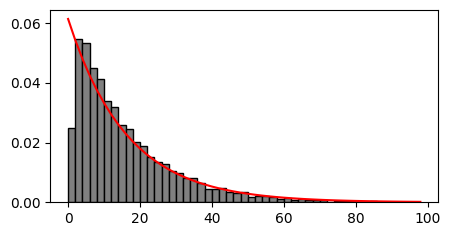

In [ ]:
from math import log
from random import random
from statistics import mean,stdev
import matplotlib.pyplot as plt
from numba import jit
import numpy as np
from math import exp
from scipy.stats import kstest,expon
@jit(nopython=True)
def f():
  l_l=1
  l_s=1.1
  t=0
  infi=1000000000
  ts=infi
  tl=0
  l=0
  while l<5:
    t=min(tl,ts)
    if t==tl:
      l=l+1
      tl=t-(1/l_l)*log(random())
      if l==1:
        ts=t-(1/l_s)*log(random())
    else:
      l=l-1
      if l==0:
        ts=infi
      else:
        ts=t-(1./l_s)*log(random())
  return t
nr=10000
l=[]
for i in range(nr):
  t=f()
  if i<10:
    print(t)
  l.append(t)
m=mean(l)
print(m)
b=[]
x=0
while x<100:
  b.append(x)
  x=x+2
alfa=1/m
ks=kstest(l,'expon',args=[alfa])
print(ks)
ly=[]
for x in b:
  ly.append(alfa*exp(-alfa*x))
plt.figure(figsize=(5,2.5))
plt.hist(l,bins=b,density=1,color='grey',edgecolor='black')
plt.plot(b,ly,color='red')
plt.show()

0.357665
15.0 4.0
7.950614 3.6075856244416484


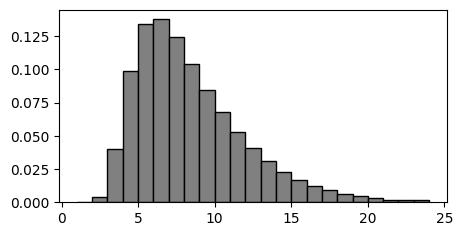

In [ ]:
from math import log
from random import random
from numba import jit
from statistics import mean,stdev
import numpy as np
import matplotlib.pyplot as plt
@jit(nopython=True)
def f():
  T=30
  l_l=1
  l_s=1.1
  t=0
  infi=100000000
  ts=infi
  tl=0
  l=0
  maxi=0

  while min(tl,ts)<T:
    t=min(tl,ts)
    if t==tl:
      l=l+1
      tl=t-(1/l_l)*log(random())
      if l==1:
        ts=t-(1/l_s)*log(random())

    else:
      l=l-1
      if l==0:
          ts=infi
      else:
          ts=t-(1./l_s)*log(random())
    if l>maxi:
        maxi=l
  return maxi


nr=1000000
l=[]
cuenta=0
for i in range(nr):
  x=f()
  l.append(x)
  if x>8:
    cuenta=cuenta+1
print(cuenta/nr)
print(np.quantile(l,0.95),np.quantile(l,0.05))
m=mean(l)
o=stdev(l)
print(m,o)
b=[]
x=1
while x<25:
  b.append(x)
  x=x+1
plt.figure(figsize=(5,2.5))
plt.hist(l,bins=b,density=1,color='grey',edgecolor='black')
plt.show()